
Develop a Convolutional Neural Network (CNN) to classify images of fruits and vegetables into two broad categories: 'Fruit' and 'Vegetable'. The dataset is located in Google Drive at "/content/drive/MyDrive/test/". The task includes preparing and preprocessing the image data, building and training the CNN model, evaluating its performance using metrics like accuracy, precision, recall, F1-score, and a confusion matrix, and visualizing training history and sample predictions.

## Prepare Data and Environment

### Subtask:
Mount Google Drive to access the dataset > Define the root directory for the images and establish a mapping between the specific fruit/vegetable names (from subdirectories) and the two main categories: 'Fruit' and 'Vegetable'. 



Mount Google Drive to access the dataset as instructed.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [ ]:
import os
import pandas as pd

# 2. Define the base path for your dataset
ROOT_DIR = '/content/drive/MyDrive/test/'

# 3. Create a dictionary that maps specific fruit/vegetable names to broad categories
category_mapping = {
    'Fruit': ['banana', 'apple', 'orange', 'strawberry', 'grape', 'mango', 'pineapple', 'watermelon'],
    'Vegetable': ['carrot', 'potato', 'onion', 'tomato', 'broccoli', 'spinach', 'bell pepper', 'cucumber']
}

# Reverse mapping for easier lookup during iteration
reverse_category_mapping = {}
for broad_cat, items in category_mapping.items():
    for item in items:
        reverse_category_mapping[item] = broad_cat

# 4. Create an empty list to store image data
image_data = []

# 5. Iterate through each broad category (Fruit and Vegetable)
# 6. For each category, iterate through its corresponding subdirectories
for broad_category, specific_items in category_mapping.items():
    for item_name in specific_items:
        item_path = os.path.join(ROOT_DIR, item_name)
        if os.path.isdir(item_path):
            # 7. Inside each subdirectory, list all image files
            for img_file in os.listdir(item_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_full_path = os.path.join(item_path, img_file)
                    # 8. For each image file, append its full path and its broad category label
                    image_data.append({'filepath': img_full_path, 'label': broad_category})

# 9. Convert the list of image paths and labels into a Pandas DataFrame
df_images = pd.DataFrame(image_data)

print(f"Total images found: {len(df_images)}")
print("DataFrame head:")
print(df_images.head())
print("Label distribution:")
print(df_images['label'].value_counts())

Total images found: 129
DataFrame head:
                                          filepath  label
0   /content/drive/MyDrive/test/banana/Image_1.jpg  Fruit
1   /content/drive/MyDrive/test/banana/Image_8.jpg  Fruit
2  /content/drive/MyDrive/test/banana/Image_10.jpg  Fruit
3   /content/drive/MyDrive/test/banana/Image_2.jpg  Fruit
4   /content/drive/MyDrive/test/banana/Image_5.jpg  Fruit
Label distribution:
label
Vegetable    70
Fruit        59
Name: count, dtype: int64


## Preprocess Images and Create Data Generators

### Subtask:




The next step is to load and preprocess images, split the data into training and validation sets, and create data generators using `ImageDataGenerator` as per the subtask instructions. This involves importing necessary libraries, defining image parameters, and configuring the generators with appropriate preprocessing and augmentation settings.



In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Split df_images into training and validation sets
train_df, val_df = train_test_split(df_images, test_size=0.2, random_state=42, stratify=df_images['label'])

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print("\nTraining set label distribution:")
print(train_df['label'].value_counts())
print("\nValidation set label distribution:")
print(val_df['label'].value_counts())

# 3. Define image dimensions and batch size
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# 4. Create an instance of ImageDataGenerator for the training data (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=20,          # Rotate images by up to 20 degrees
    width_shift_range=0.2,      # Shift images horizontally by up to 20% of width
    height_shift_range=0.2,     # Shift images vertically by up to 20% of height
    shear_range=0.2,            # Shear transformations
    zoom_range=0.2,             # Zoom in/out by up to 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'         # Fill newly created pixels with the nearest value
)

# 5. Create another instance of ImageDataGenerator for the validation data (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# 6. Create a training data generator using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# 7. Create a validation data generator using flow_from_dataframe
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # No shuffling for validation set
)

# 8. Print the class indices from the training generator
print("\nClass indices from train_generator:")
print(train_generator.class_indices)

Training set size: 103
Validation set size: 26

Training set label distribution:
label
Vegetable    56
Fruit        47
Name: count, dtype: int64

Validation set label distribution:
label
Vegetable    14
Fruit        12
Name: count, dtype: int64
Found 103 validated image filenames belonging to 2 classes.
Found 26 validated image filenames belonging to 2 classes.

Class indices from train_generator:
{'Fruit': 0, 'Vegetable': 1}


## Build and Compile CNN Model

### Subtask:
Design and construct a Convolutional Neural Network (CNN) architecture suitable for image classification using Keras. Compile the model, specifying an appropriate optimizer (e.g., Adam), a loss function (e.g., binary cross-entropy for two classes), and evaluation metrics (e.g., accuracy).


 design and compile a Convolutional Neural Network (CNN) model using Keras, following the instructions to include specific layers, activation functions, and compilation settings.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# 2. Initialize a Sequential model
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Explicitly define input shape using Input layer
    # 3. Add convolutional layers (Conv2D) with activation functions ('relu') and pooling layers (MaxPooling2D)
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 4. Add a Flatten layer to convert the 2D feature maps into a 1D vector
    Flatten(),

    # 5. Add one or more Dense (fully connected) layers with 'relu' activation
    Dense(128, activation='relu'),

    # 6. Include Dropout layers after dense layers to prevent overfitting
    Dropout(0.5),

    # 7. Add the final output Dense layer with a single unit and 'sigmoid' activation for binary classification
    Dense(1, activation='sigmoid')
])

# 8. Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model.summary()

print("CNN model built and compiled successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model built and compiled successfully.


## Train the Model

### Subtask:
Train the compiled CNN model using the prepared training data generator. Monitor the model's performance on the validation set during the training process to track accuracy and loss over epochs.


 the model using the `fit()` method with the `train_generator` and `val_generator`, specify the number of epochs, and store the training history as instructed in the subtask.



In [ ]:
import math

EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=math.ceil(train_generator.samples / BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=math.ceil(val_generator.samples / BATCH_SIZE)
)

print("Model training complete.")

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.6893 - loss: 0.5996 - val_accuracy: 0.6154 - val_loss: 0.5278
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6117 - loss: 0.6131 - val_accuracy: 0.7692 - val_loss: 0.5513
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6408 - loss: 0.5686 - val_accuracy: 0.6923 - val_loss: 0.5242
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6214 - loss: 0.6590 - val_accuracy: 0.7308 - val_loss: 0.6177
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6893 - loss: 0.5659 - val_accuracy: 0.6538 - val_loss: 0.4659
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6893 - loss: 0.5307 - val_accuracy: 0.6923 - val_loss: 0.4598
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6699 - loss: 0.5565 - val_accuracy: 0.6923 - val_loss: 0.5208
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6893 - loss: 0.5482 - val_accuracy: 0.7692 - val_loss: 0.6058
Epoch 9/

## Evaluate Model Performance

### Subtask:
Assess the trained model's performance on the unseen validation dataset. Calculate and display key classification metrics such as accuracy, precision, recall, and F1-score. Generate and visualize a confusion matrix to understand classification errors.


 generate predictions for the validation set, calculate classification metrics, and visualize the confusion matrix to evaluate the model's performance.



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Accuracy: 0.7692
Precision: 0.8333
Recall: 0.7143
F1-Score: 0.7692


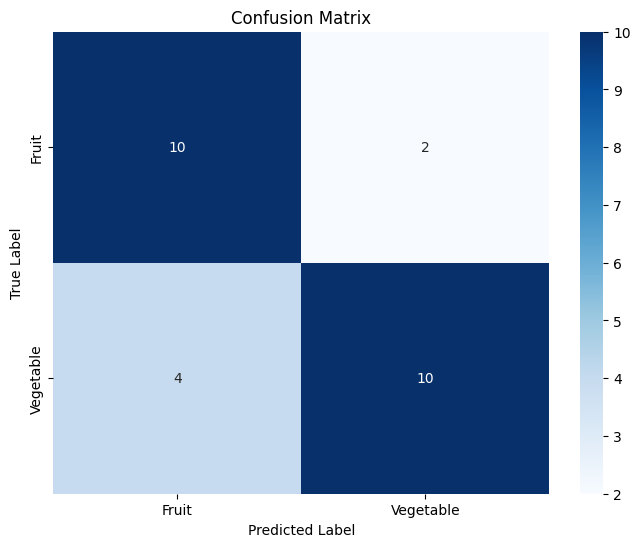

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Generate predictions for the validation set
# Reset the generator to ensure predictions start from the beginning
val_generator.reset()
predictions = model.predict(val_generator)

# Convert predicted probabilities to binary class labels (0 or 1) using a threshold of 0.5
predicted_labels = (predictions > 0.5).astype(int)

# 2. Obtain the true labels from the val_generator
true_labels = val_generator.classes

# 3. Calculate and print classification metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 4. Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# 5. Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(train_generator.class_indices.keys()),
            yticklabels=list(train_generator.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Visualize Training History and Predictions

### Subtask:



 generate plots for the model's training history (accuracy and loss) and display sample image predictions from the validation set, as outlined in the subtask instructions. This involves utilizing the `history` object from model training and performing image preprocessing and prediction for selected samples.



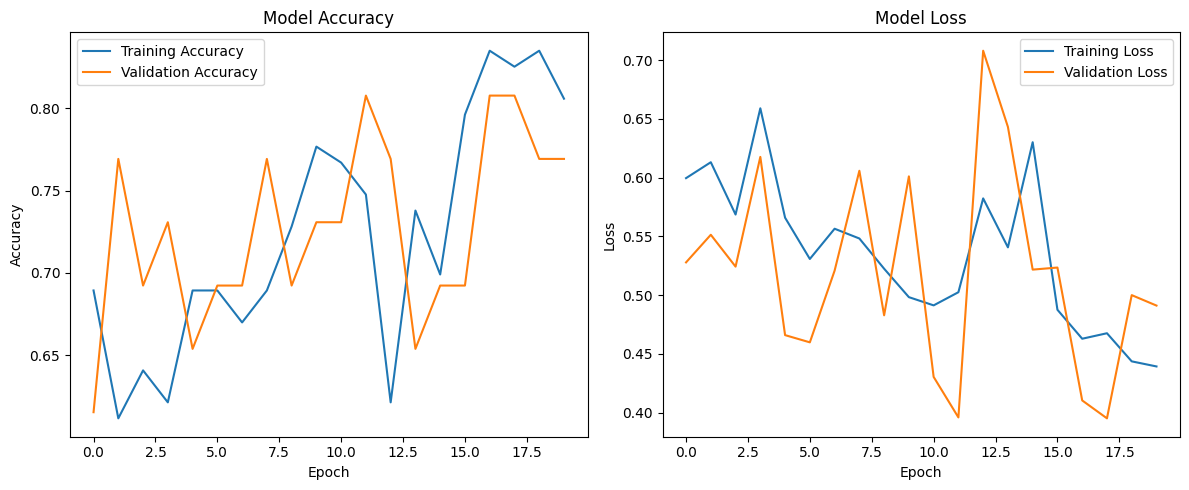

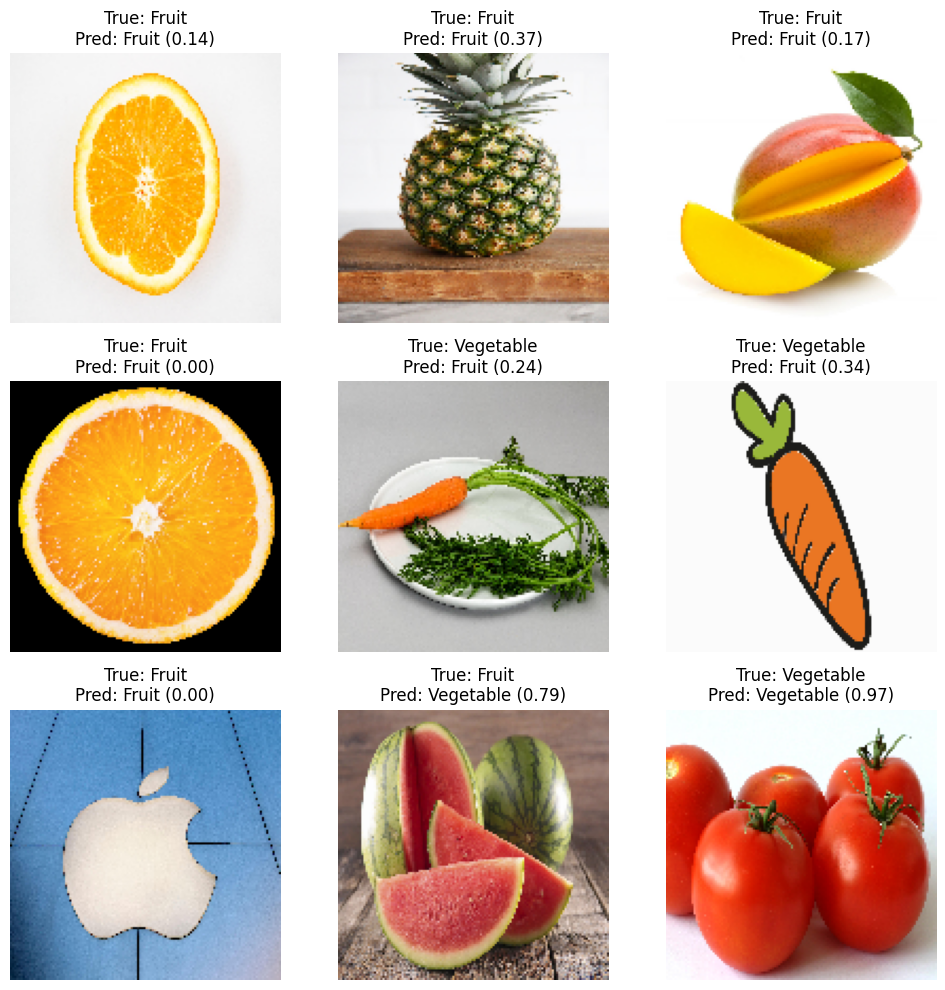

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# 1. Plot training history for accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# 2. Plot training history for loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Display sample predictions
# Get class names from train_generator.class_indices
class_names = {v: k for k, v in train_generator.class_indices.items()}

# Randomly select a small number of images from val_df
sample_images_df = val_df.sample(n=9, random_state=42) # Select 9 images for a 3x3 grid

plt.figure(figsize=(10, 10))
for i, (index, row) in enumerate(sample_images_df.iterrows()):
    filepath = row['filepath']
    true_label = row['label']

    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0 # Normalize
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # Make prediction
    prediction = model.predict(img_array, verbose=0)[0][0]
    predicted_class_index = (prediction > 0.5).astype(int)
    predicted_label = class_names[predicted_class_index]

    # Display image and labels
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {predicted_label} ({prediction:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()